### 1. replicates DTU documentation


In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from py_wake.wind_turbines import WindTurbines
from py_wake.wind_farm_models.external_wind_farm_models import ExternalXRAbsWindFarm, ExternalXRRelWindFarm, ExternalWFMWindFarm
from py_wake.wind_farm_models.engineering_models import PropagateDownwind
from py_wake.deficit_models import BastankhahGaussianDeficit
from py_wake.superposition_models import LinearSum
from py_wake.flow_map import XYGrid
from py_wake.examples.data.hornsrev1 import Hornsrev1Site, V80
from py_wake.utils import layouts


SIM_WD = list(range(0, 360, 30))
site = Hornsrev1Site()


def wfm_for(wts, external_farms=[]):
    return PropagateDownwind(site, wts, wake_deficitModel=BastankhahGaussianDeficit(use_effective_ws=True),
                             superpositionModel=LinearSum(), externalWindFarms=external_farms)


def aep_table(wfm_merged, wfm_ext, all_x, all_y, self_x, self_y, self_wt_idx):
    rows = []
    for wd in SIM_WD:
        m = float(wfm_merged(all_x, all_y, type=0, wd=[wd], ws=[10]).aep().isel(wt=self_wt_idx).sum().values)
        e = float(wfm_ext(self_x, self_y, type=0, wd=[wd], ws=[10]).aep().isel(wt=np.arange(len(self_x))).sum().values)
        rows.append(dict(wd=wd, merged_GWh=m, external_GWh=e, error_pct=(m - e) / m * 100))
    df = pd.DataFrame(rows)
    df.loc["TOTAL"] = ["TOTAL", df.merged_GWh.sum(), df.external_GWh.sum(),
                        (df.merged_GWh.sum() - df.external_GWh.sum()) / df.merged_GWh.sum() * 100]
    return df.round(3)

/opt/anaconda3/envs/wesl_jul_31/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
wt6 = WindTurbines.from_WindTurbine_lst([V80()] * 6)
wf_x, wf_y = layouts.circular([1, 5, 12, 18], 1800)
H = wt6.hub_height()
neighbours = [(wf_x + 6000*np.cos(d), wf_y + 6000*np.sin(d), (90 - np.rad2deg(d)) % 360)
              for d in np.linspace(0, 2*np.pi, 5, endpoint=False)]

wfm_ref1 = wfm_for(wt6)
wfm_merged1 = wfm_for(wt6)
all_x1 = np.r_[wf_x, np.concatenate([nx for nx, ny, a in neighbours])]
all_y1 = np.r_[wf_y, np.concatenate([ny for nx, ny, a in neighbours])]
self_idx1 = np.arange(len(wf_x))

ext_abs, ext_rel = [], []
for i, (nx, ny, angle) in enumerate(neighbours, 1):
    wd_lst = (np.arange(-45, 45) + angle) % 360
    grid_abs = (np.linspace(wf_x.min()-1000, wf_x.max()+1000, 20), np.linspace(wf_y.min()-1000, wf_y.max()+1000, 20), np.array([H]))
    ext_abs.append(ExternalXRAbsWindFarm.generate(f"WF{i}", grid_abs, wfm_ref1, wt_x=list(nx), wt_y=list(ny), wd=wd_lst, ws=[10]))
    grid_rel = (np.linspace(3000, 9000, 20), np.linspace(-3000, 3000, 20), np.array([0]))
    ext_rel.append(ExternalXRRelWindFarm.generate(f"WF{i}", grid_rel, wfm_ref1, wt_x=list(nx), wt_y=list(ny), wd=wd_lst, ws=[10]))

wfm_abs1 = wfm_for(wt6, ext_abs)
wfm_rel1 = wfm_for(wt6, ext_rel)

df_abs1 = aep_table(wfm_merged1, wfm_abs1, all_x1, all_y1, wf_x, wf_y, self_idx1)
df_rel1 = aep_table(wfm_merged1, wfm_rel1, all_x1, all_y1, wf_x, wf_y, self_idx1)
print(df_abs1.to_string(index=False))
print()
print(df_rel1.to_string(index=False))

   wd  merged_GWh  external_GWh  error_pct
    0      13.313        13.309      0.030
   30      13.024        13.061     -0.288
   60      20.118        20.105      0.067
   90      22.814        23.139     -1.424
  120      37.432        37.407      0.067
  150      22.404        22.468     -0.288
  180      35.099        35.088      0.030
  210      41.765        41.733      0.076
  240      54.095        54.155     -0.112
  270      49.345        49.347     -0.004
  300      37.133        37.174     -0.112
  330      16.865        16.852      0.076
TOTAL     363.406       363.839     -0.119

   wd  merged_GWh  external_GWh  error_pct
    0      13.313        13.317     -0.025
   30      13.024        13.078     -0.420
   60      20.118        20.103      0.073
   90      22.814        23.098     -1.244
  120      37.432        37.404      0.073
  150      22.404        22.498     -0.420
  180      35.099        35.108     -0.025
  210      41.765        41.753      0.030
  240     

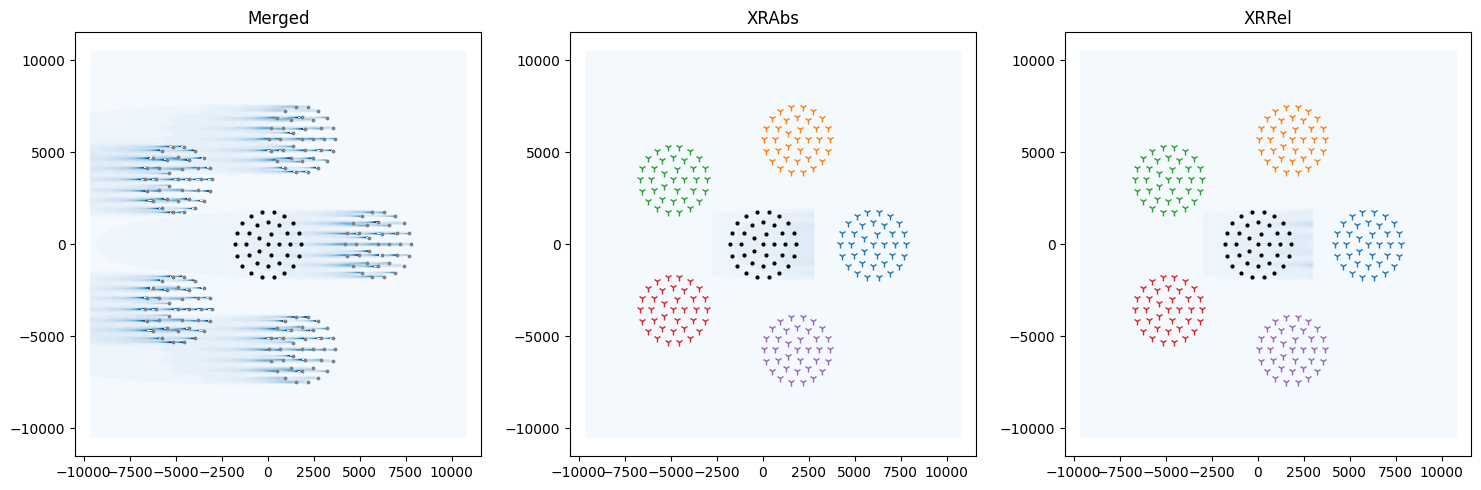

In [3]:
all_nb_x1 = np.concatenate([nx for nx, ny, a in neighbours])
all_nb_y1 = np.concatenate([ny for nx, ny, a in neighbours])
grid1 = XYGrid(x=np.linspace(all_x1.min()-3000, all_x1.max()+3000, 200), y=np.linspace(all_y1.min()-3000, all_y1.max()+3000, 200))

WD1 = 90
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sim_m1 = wfm_merged1(all_nb_x1, all_nb_y1, type=0, wd=[WD1], ws=[10])
sim_m1.flow_map(grid1, wd=WD1, ws=10).plot_wake_map(ax=axes[0], levels=np.linspace(6, 10, 30), plot_colorbar=False, plot_windturbines=False)
axes[0].scatter(all_nb_x1, all_nb_y1, s=3, c="gray")
axes[0].scatter(wf_x, wf_y, s=4, c="black")
axes[0].set_aspect("equal")
axes[0].set_title("Merged")

sim_a1 = wfm_abs1([], [], wd=[WD1], ws=[10])
sim_a1.flow_map(grid1, wd=WD1, ws=10).plot_wake_map(ax=axes[1], levels=np.linspace(6, 10, 30), plot_colorbar=False)
axes[1].scatter(wf_x, wf_y, s=4, c="black")
axes[1].set_aspect("equal")
axes[1].set_title("XRAbs")

sim_r1 = wfm_rel1([], [], wd=[WD1], ws=[10])
sim_r1.flow_map(grid1, wd=WD1, ws=10).plot_wake_map(ax=axes[2], levels=np.linspace(6, 10, 30), plot_colorbar=False)
axes[2].scatter(wf_x, wf_y, s=4, c="black")
axes[2].set_aspect("equal")
axes[2].set_title("XRRel")
fig.tight_layout()
plt.show()

### 2. honey comb idea


In [4]:
N_RING, TURB_D, HEX_R = 6, 1800, 2200
HEX_SPACING = np.sqrt(3) * HEX_R
wt7 = WindTurbines.from_WindTurbine_lst([V80()] * 7)
toy_H = wt7.hub_height()
ring_angles = np.arange(N_RING) * 60.0
centres_x = np.r_[0.0, HEX_SPACING * np.cos(np.deg2rad(ring_angles))]
centres_y = np.r_[0.0, HEX_SPACING * np.sin(np.deg2rad(ring_angles))]
nb_bearing = (90 - ring_angles) % 360


def farm_turbines(cx, cy):
    x, y = layouts.circular([1, 5, 12, 18], TURB_D)
    return x + cx, y + cy


farm_xy = [farm_turbines(cx, cy) for cx, cy in zip(centres_x, centres_y)]
farm_x, farm_y = zip(*farm_xy)
self_x, self_y = np.asarray(farm_x[0]), np.asarray(farm_y[0])
nb_x, nb_y = farm_x[1:], farm_y[1:]
all_x, all_y = np.concatenate(farm_x), np.concatenate(farm_y)
self_idx = np.arange(len(self_x))

wfm_ref = wfm_for(wt7)
wfm_merged = wfm_for(wt7)


def build_ext_farms(half_width=45, grid_n=20, ws=[10]):
    xmin, xmax = self_x.min() - 1000, self_x.max() + 1000
    ymin, ymax = self_y.min() - 1000, self_y.max() + 1000
    grid_xyh = (np.linspace(xmin, xmax, grid_n), np.linspace(ymin, ymax, grid_n), np.array([toy_H]))
    farms = []
    for i in range(N_RING):
        wd_lst = (np.arange(-half_width, half_width) + nb_bearing[i]) % 360
        farms.append(ExternalXRAbsWindFarm.generate(f"WF{i+1}", grid_xyh, wfm_ref, wt_x=list(nb_x[i]), wt_y=list(nb_y[i]), wd=wd_lst, ws=ws))
    return farms


ext_baseline = build_ext_farms(45, 20)
wfm_ext_baseline = wfm_for(wt7, ext_baseline)
df2 = aep_table(wfm_merged, wfm_ext_baseline, all_x, all_y, self_x, self_y, self_idx)
print(df2.to_string(index=False))

   wd  merged_GWh  external_GWh  error_pct
    0      11.651        10.888      6.549
   30       9.676        11.748    -21.418
   60      17.131        16.525      3.534
   90      17.496        22.213    -26.959
  120      31.873        30.747      3.534
  150      16.644        20.209    -21.418
  180      30.718        28.706      6.549
  210      29.891        36.244    -21.254
  240      49.437        47.758      3.396
  270      34.542        43.883    -27.040
  300      33.935        32.783      3.396
  330      12.070        14.636    -21.254
TOTAL     295.065       316.340     -7.210


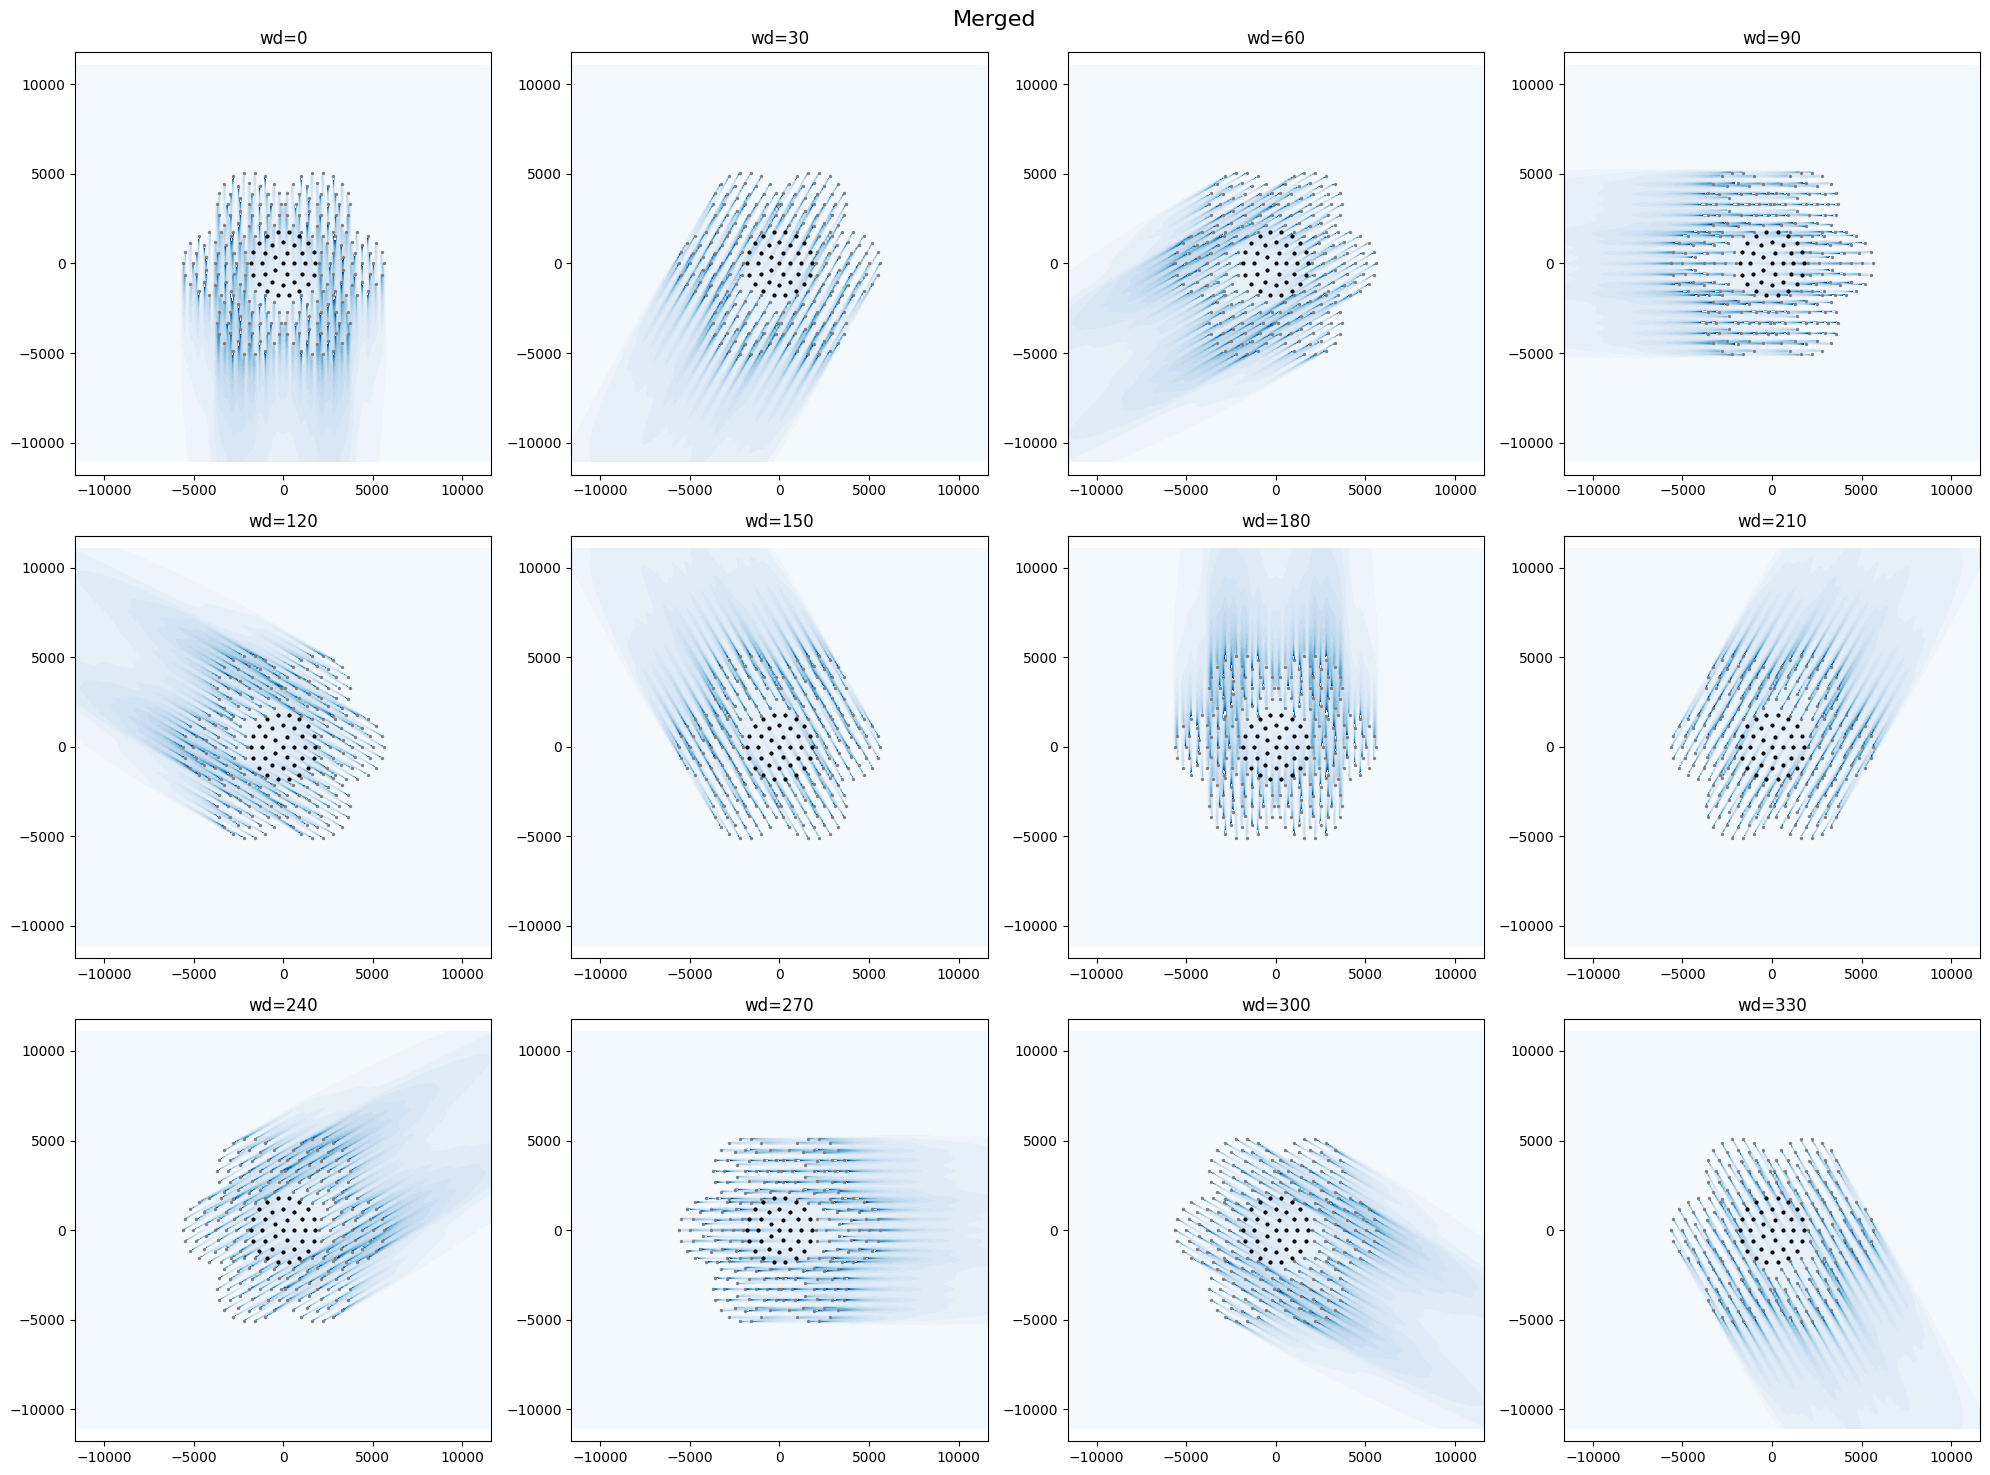

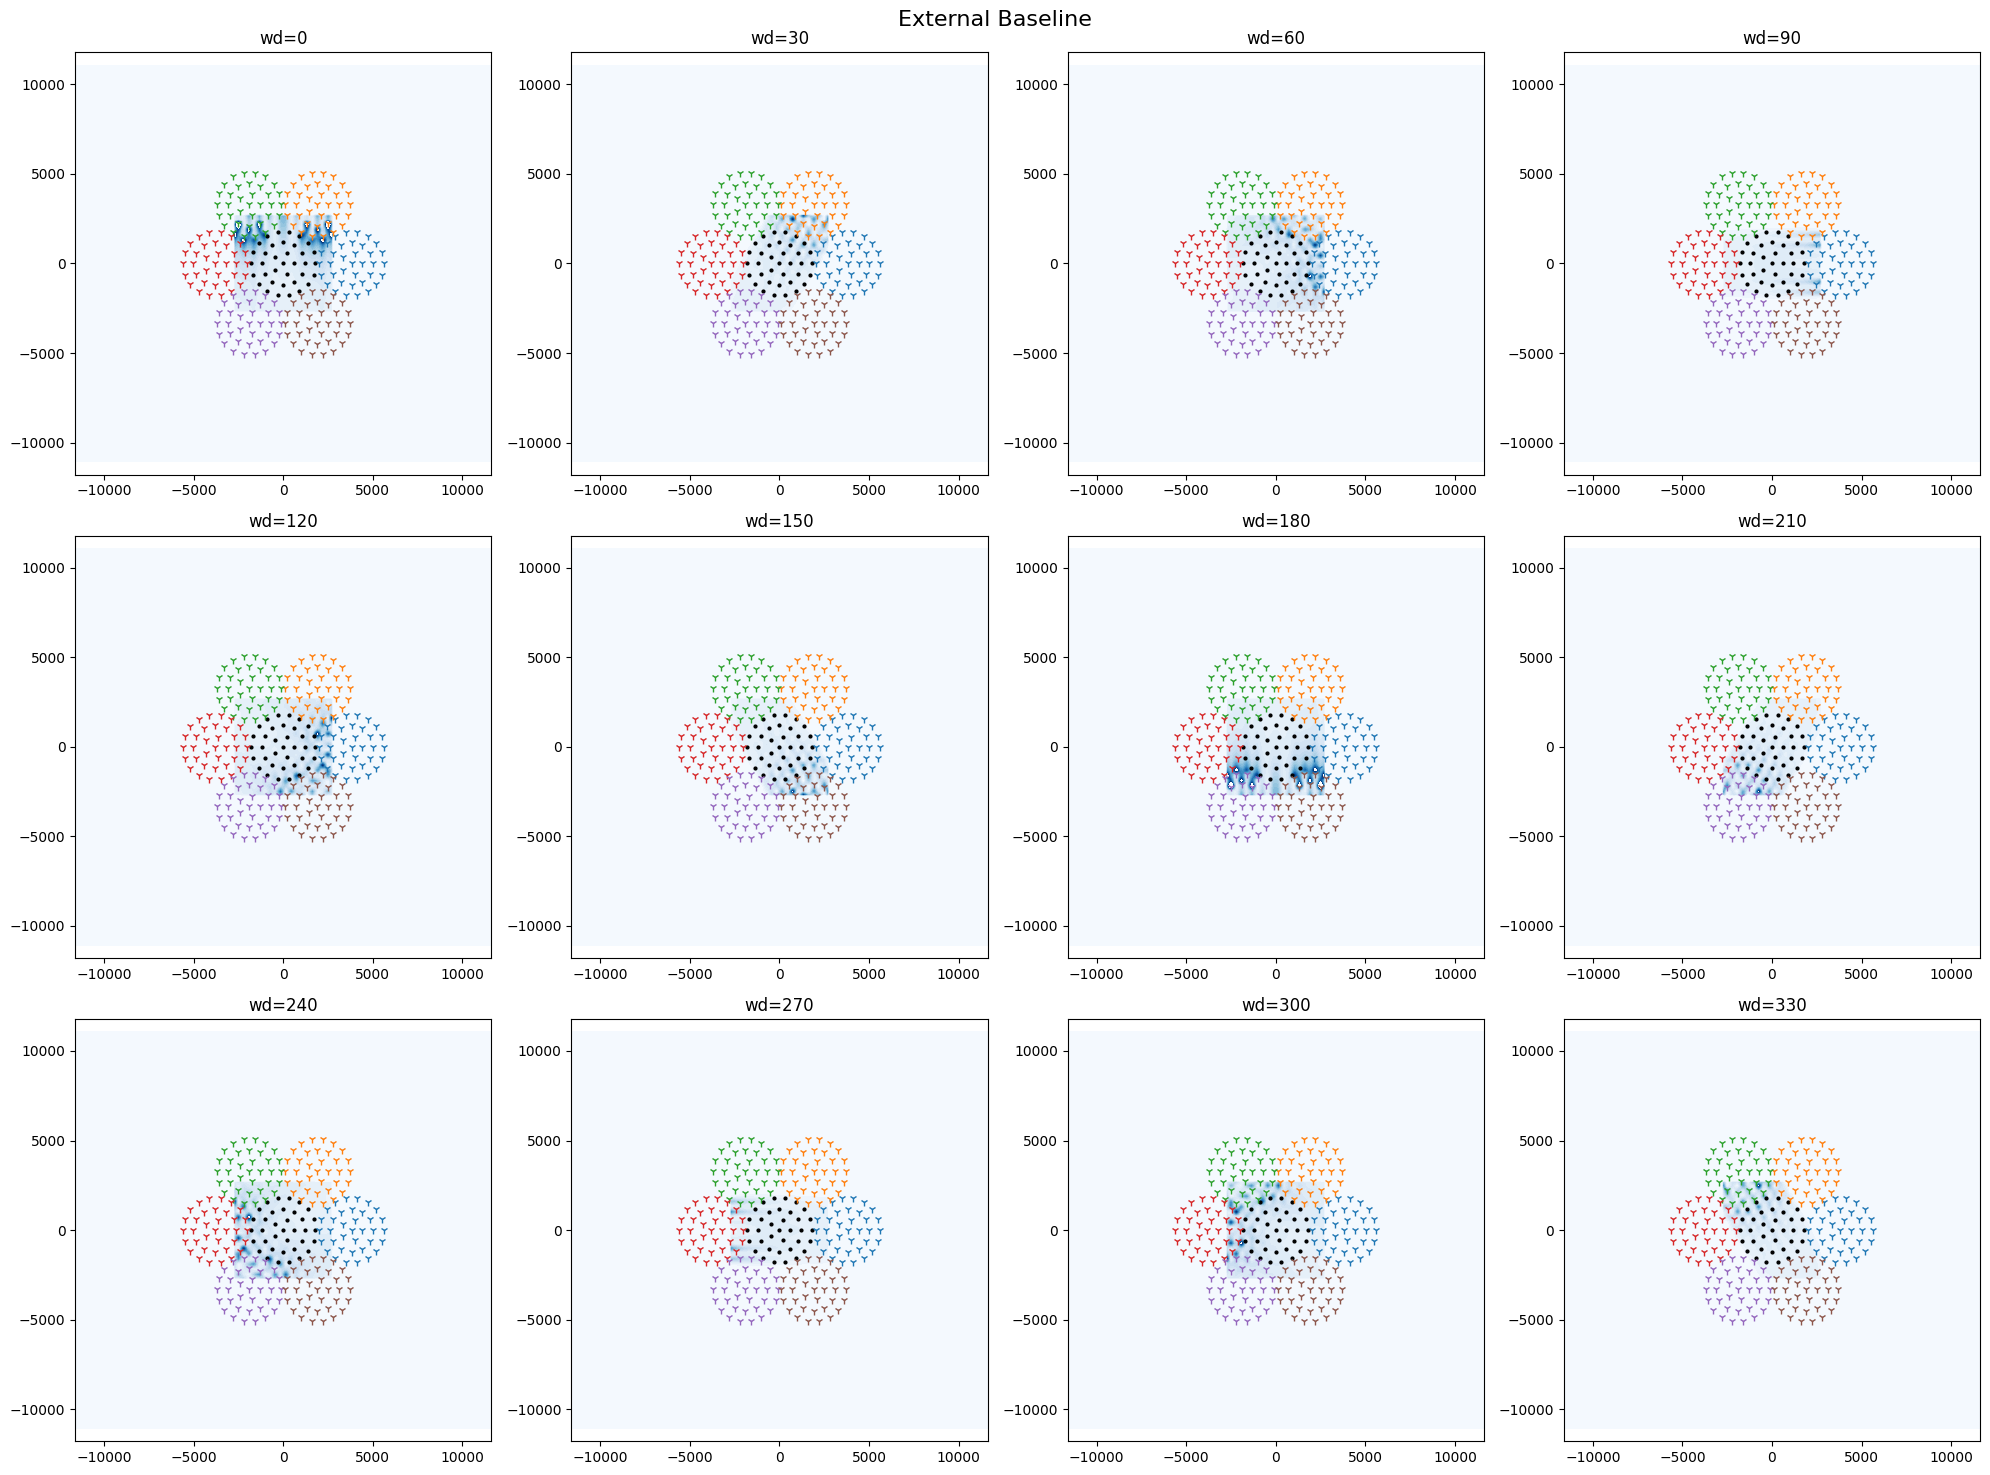

In [5]:
all_nb_x, all_nb_y = np.concatenate(nb_x), np.concatenate(nb_y)
m = 6000
grid2 = XYGrid(x=np.linspace(all_x.min()-m, all_x.max()+m, 220), y=np.linspace(all_y.min()-m, all_y.max()+m, 220))

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
for ax, wd in zip(axes.flat, SIM_WD):
    sim = wfm_merged(all_nb_x, all_nb_y, type=0, wd=[wd], ws=[10])
    sim.flow_map(grid2, wd=wd, ws=10).plot_wake_map(ax=ax, levels=np.linspace(6, 10, 30), plot_colorbar=False, plot_windturbines=False)
    ax.scatter(all_nb_x, all_nb_y, s=2, c="gray")
    ax.scatter(self_x, self_y, s=4, c="black")
    ax.set_aspect("equal")
    ax.set_title(f"wd={wd}")
fig.suptitle("Merged", fontsize=16)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
for ax, wd in zip(axes.flat, SIM_WD):
    sim = wfm_ext_baseline([], [], wd=[wd], ws=[10])
    sim.flow_map(grid2, wd=wd, ws=10).plot_wake_map(ax=ax, levels=np.linspace(6, 10, 30), plot_colorbar=False)
    ax.scatter(self_x, self_y, s=4, c="black")
    ax.set_aspect("equal")
    ax.set_title(f"wd={wd}")
fig.suptitle("External Baseline", fontsize=16)
fig.tight_layout()
plt.show()

### 3. fix grid size, first test

In [6]:
rows_w = []
for half_width in [45, 90, 135]:
    ext = [ExternalWFMWindFarm(f"WF{i+1}", wfm_ref, wt_x=list(nb_x[i]), wt_y=list(nb_y[i]),
                               include_wd=(np.arange(-half_width, half_width) + nb_bearing[i]) % 360) for i in range(N_RING)]
    df = aep_table(wfm_merged, wfm_for(wt7, ext), all_x, all_y, self_x, self_y, self_idx)
    rows_w.append(dict(half_width=half_width, error_pct=df.loc["TOTAL", "error_pct"]))
print(pd.DataFrame(rows_w).round(3).to_string(index=False))

rows_g = []
for grid_n in [20, 40, 60]:
    ext = build_ext_farms(90, grid_n)
    df = aep_table(wfm_merged, wfm_for(wt7, ext), all_x, all_y, self_x, self_y, self_idx)
    rows_g.append(dict(grid_n=grid_n, error_pct=df.loc["TOTAL", "error_pct"]))
print(pd.DataFrame(rows_g).round(3).to_string(index=False))

 half_width  error_pct
         45     -4.019
         90      0.332
        135      0.332


 grid_n  error_pct
     20     -4.353
     40     -1.465
     60      0.012


In [7]:
ext_fixed = build_ext_farms(90, 60)
wfm_ext_fixed = wfm_for(wt7, ext_fixed)
df3 = aep_table(wfm_merged, wfm_ext_fixed, all_x, all_y, self_x, self_y, self_idx)
print(df3.to_string(index=False))

   wd  merged_GWh  external_GWh  error_pct
    0      11.651        11.609      0.366
   30       9.676         9.802     -1.300
   60      17.131        16.928      1.183
   90      17.496        17.761     -1.515
  120      31.873        31.496      1.183
  150      16.644        16.861     -1.300
  180      30.718        30.606      0.366
  210      29.891        30.290     -1.336
  240      49.437        48.874      1.139
  270      34.542        35.022     -1.390
  300      33.935        33.549      1.139
  330      12.070        12.231     -1.336
TOTAL     295.065       295.029      0.012


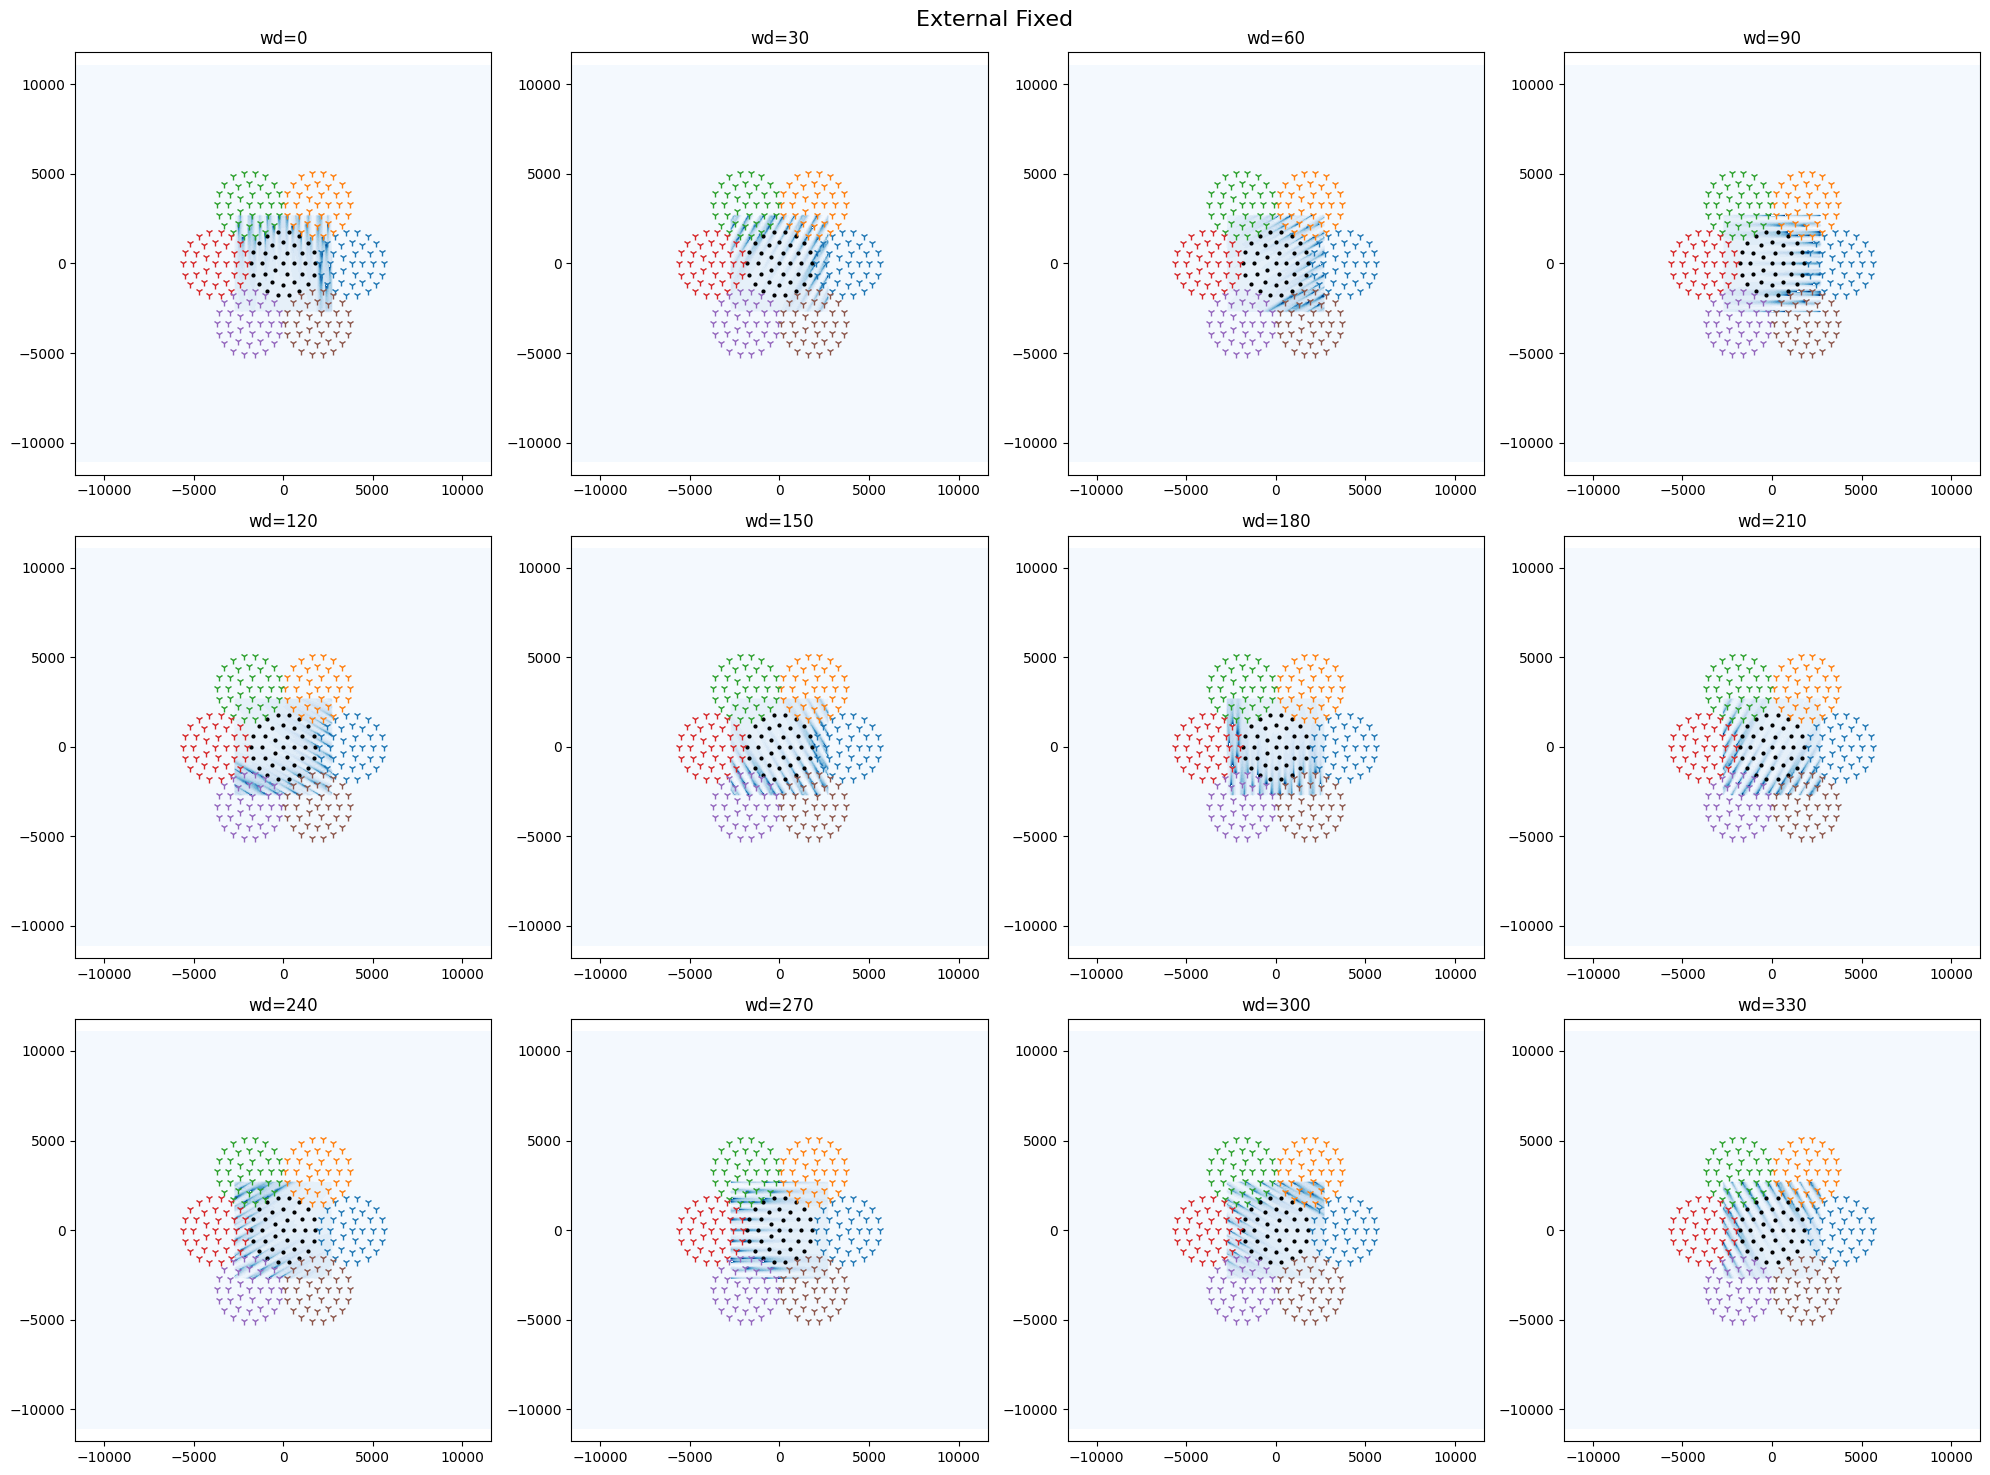

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
for ax, wd in zip(axes.flat, SIM_WD):
    sim = wfm_ext_fixed([], [], wd=[wd], ws=[10])
    sim.flow_map(grid2, wd=wd, ws=10).plot_wake_map(ax=ax, levels=np.linspace(6, 10, 30), plot_colorbar=False)
    ax.scatter(self_x, self_y, s=4, c="black")
    ax.set_aspect("equal")
    ax.set_title(f"wd={wd}")
fig.suptitle("External Fixed", fontsize=16)
fig.tight_layout()
plt.show()

### 4. honeycomb border

In [9]:
SELF_IDX = 1
other_idx = [i for i in range(7) if i != SELF_IDX]
self_x2, self_y2 = np.asarray(farm_x[SELF_IDX]), np.asarray(farm_y[SELF_IDX])
nb_x2 = [farm_x[i] for i in other_idx]
nb_y2 = [farm_y[i] for i in other_idx]
all_x2, all_y2 = np.concatenate(farm_x), np.concatenate(farm_y)
self_off = sum(len(farm_x[i]) for i in range(SELF_IDX))
self_idx2 = np.arange(self_off, self_off + len(self_x2))

dx = centres_x[other_idx] - centres_x[SELF_IDX]
dy = centres_y[other_idx] - centres_y[SELF_IDX]
nb_bearing2 = (90 - np.rad2deg(np.arctan2(dy, dx))) % 360
touching2 = np.isclose(np.hypot(dx, dy), HEX_SPACING, rtol=0.02)

wfm_merged2 = wfm_for(wt7)


def build_ext_farms2(global_recipe=False, ws=[10]):
    xmin, xmax = self_x2.min() - 1000, self_x2.max() + 1000
    ymin, ymax = self_y2.min() - 1000, self_y2.max() + 1000
    farms = []
    for k, i in enumerate(other_idx):
        hw, gn = (90, 60) if (global_recipe or touching2[k]) else (45, 20)
        grid_xyh = (np.linspace(xmin, xmax, gn), np.linspace(ymin, ymax, gn), np.array([toy_H]))
        wd_lst = (np.arange(-hw, hw) + nb_bearing2[k]) % 360
        farms.append(ExternalXRAbsWindFarm.generate(f"nb{i}", grid_xyh, wfm_ref, wt_x=list(nb_x2[k]), wt_y=list(nb_y2[k]), wd=wd_lst, ws=ws))
    return farms


wfm_ext2 = wfm_for(wt7, build_ext_farms2())
df4 = aep_table(wfm_merged2, wfm_ext2, all_x2, all_y2, self_x2, self_y2, self_idx2)
print(df4.to_string(index=False))

wfm_ext2_global = wfm_for(wt7, build_ext_farms2(global_recipe=True))
df4b = aep_table(wfm_merged2, wfm_ext2_global, all_x2, all_y2, self_x2, self_y2, self_idx2)
print(df4b.loc[["TOTAL"]].to_string(index=False))

   wd  merged_GWh  external_GWh  error_pct
    0      12.829        12.810      0.150
   30      13.444        13.467     -0.169
   60      20.475        20.475     -0.000
   90      25.336        25.336      0.000
  120      38.096        38.096      0.000
  150      23.127        23.166     -0.169
  180      33.823        33.772      0.150
  210      31.119        31.491     -1.195
  240      45.072        44.137      2.075
  270      31.953        31.485      1.465
  300      30.939        30.297      2.075
  330      12.566        12.716     -1.195
TOTAL     318.779       317.248      0.480


   wd  merged_GWh  external_GWh  error_pct
TOTAL     318.779       317.116      0.522


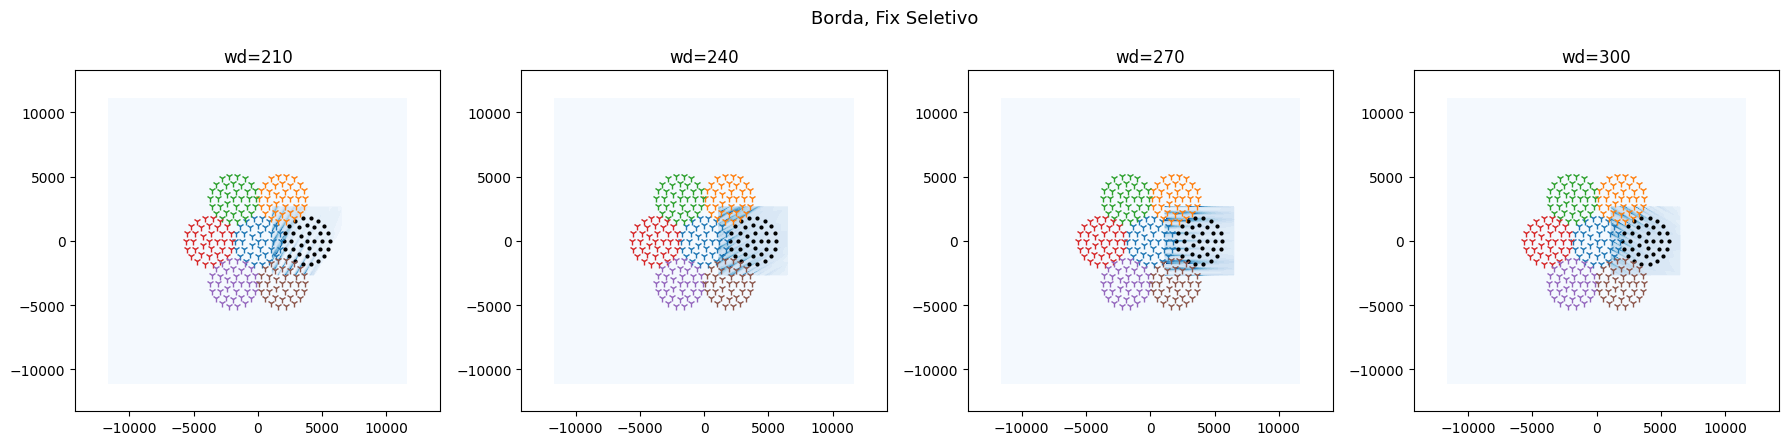

In [10]:
edge_wds = [210, 240, 270, 300]
fig, axes = plt.subplots(1, len(edge_wds), figsize=(4.5*len(edge_wds), 4.5))
for ax, wd in zip(axes, edge_wds):
    sim_e = wfm_ext2([], [], wd=[wd], ws=[10])
    sim_e.flow_map(grid2, wd=wd, ws=10).plot_wake_map(ax=ax, levels=np.linspace(6, 10, 30), plot_colorbar=False)
    ax.scatter(self_x2, self_y2, s=4, c="black")
    ax.set_aspect("equal")
    ax.set_title(f"wd={wd}")
fig.suptitle("Borda, Fix Seletivo", fontsize=13)
fig.tight_layout()
plt.show()

### 5. real Cluster (USA- MA/RI) and ordenation

In [11]:
sys.path.insert(0, "../Monte_Carlo_v3")
import cluster, turbines, grid_fill, climate
from aep import _pywake_turbine
from py_wake.deficit_models.gaussian import TurboGaussianDeficit
from py_wake.deficit_models.utils import ct2a_mom1d
from py_wake.ground_models.ground_models import Mirror
from py_wake.rotor_avg_models.gaussian_overlap_model import GaussianOverlapAvgModel
from py_wake.superposition_models import SquaredSum

INFILL_TURBINE, INFILL_SPACING_D = "13 MW", 10
rng = np.random.default_rng(0)
real_site, _ = climate.sample_site(rng)

self_name5 = cluster.FOCUS_FARM
pts = grid_fill.fill(cluster.LEASE_TEMPLATES[self_name5], turbines.diameter(INFILL_TURBINE), INFILL_SPACING_D)
self_x5, self_y5 = pts[:, 0], pts[:, 1]
self_wt5 = _pywake_turbine(INFILL_TURBINE)
self_H5 = self_wt5.hub_height()

vne_name = "Vineyard Northeast"
pts = grid_fill.fill(cluster.LEASE_TEMPLATES[vne_name], turbines.diameter(INFILL_TURBINE), INFILL_SPACING_D)
vne_x, vne_y = pts[:, 0], pts[:, 1]


def turbopark_wfm(wts, external_farms=()):
    wake_deficitModel = TurboGaussianDeficit(ct2a=ct2a_mom1d, groundModel=Mirror(superpositionModel=SquaredSum()),
                                             rotorAvgModel=GaussianOverlapAvgModel(), ctlim=0.96)
    wake_deficitModel.WS_key = "WS_jlk"
    return PropagateDownwind(real_site, wts, wake_deficitModel=wake_deficitModel,
                             superpositionModel=SquaredSum(), externalWindFarms=list(external_farms))


def bearing_deg(fx, fy, tx, ty):
    ang = np.degrees(np.arctan2(np.mean(ty) - np.mean(fy), np.mean(tx) - np.mean(fx)))
    return (90 - ang) % 360


wfm_merged5 = turbopark_wfm(WindTurbines.from_WindTurbine_lst([self_wt5]))
x5 = np.r_[self_x5, vne_x]
y5 = np.r_[self_y5, vne_y]
WD5 = 90
merged5 = float(wfm_merged5(x5, y5, type=0, wd=[WD5], ws=[10]).aep().isel(wt=np.arange(len(self_x5))).sum().values)

farm_wfm5 = turbopark_wfm(WindTurbines.from_WindTurbine_lst([self_wt5]))
angle5 = bearing_deg(self_x5, self_y5, vne_x, vne_y)
xmin5, xmax5 = self_x5.min()-1000, self_x5.max()+1000
ymin5, ymax5 = self_y5.min()-1000, self_y5.max()+1000

rows5 = []
sims5 = {}
for grid_n in [20, 60, 120]:
    grid_xyh = (np.linspace(xmin5, xmax5, grid_n), np.linspace(ymin5, ymax5, grid_n), np.array([self_H5]))
    wd_lst = (np.arange(-60, 60) + angle5) % 360
    ext5 = ExternalXRAbsWindFarm.generate("VNE", grid_xyh, farm_wfm5, wt_x=list(vne_x), wt_y=list(vne_y), wd=wd_lst, ws=[10])
    wfm_ext5 = turbopark_wfm(WindTurbines.from_WindTurbine_lst([self_wt5]), [ext5])
    sim_ext5 = wfm_ext5(self_x5, self_y5, type=0, wd=[WD5], ws=[10])
    ext_v = float(sim_ext5.aep().isel(wt=np.arange(len(self_x5))).sum().values)
    rows5.append(dict(grid_n=grid_n, merged_GWh=merged5, external_GWh=ext_v, error_pct=(merged5-ext_v)/merged5*100))
    sims5[grid_n] = sim_ext5
df5 = pd.DataFrame(rows5).round(3)
print(df5.to_string(index=False))

 grid_n  merged_GWh  external_GWh  error_pct
     20      46.589       106.336   -128.244
     60      46.589       106.336   -128.244
    120      46.589       106.336   -128.244


In [12]:
sim_merged5 = wfm_merged5(x5, y5, type=0, wd=[WD5], ws=[10])
ws_truth5 = sim_merged5.WS_eff.isel(wt=np.arange(len(self_x5)), wd=0, ws=0).values
ws_ext5 = sims5[20].WS_eff.isel(wt=np.arange(len(self_x5)), wd=0, ws=0).values

waked_truth5 = ws_truth5 < 9.9
zero_deficit5 = ws_ext5 > 9.9
n_misclassified5 = int((waked_truth5 & zero_deficit5).sum())

summary5 = pd.DataFrame([dict(n_self=len(self_x5), n_waked_truth=int(waked_truth5.sum()),
                              n_zero_deficit_external=int(zero_deficit5.sum()),
                              n_misclassified=n_misclassified5,
                              mean_ws_truth=ws_truth5.mean(), mean_ws_external=ws_ext5.mean())])
print(summary5.round(3).to_string(index=False))

 n_self  n_waked_truth  n_zero_deficit_external  n_misclassified  mean_ws_truth  mean_ws_external
    107            103                       16               12          4.954             6.614


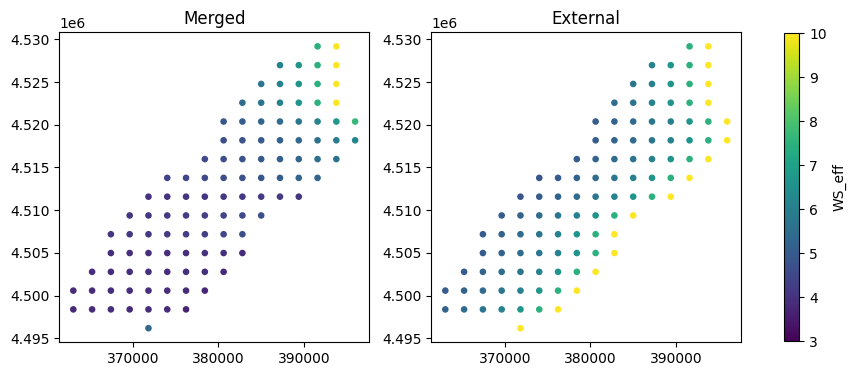

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
vmin, vmax = 3, 10
axes[0].scatter(self_x5, self_y5, c=ws_truth5, cmap="viridis", vmin=vmin, vmax=vmax, s=14)
axes[0].set_aspect("equal")
axes[0].set_title("Merged")
sc5 = axes[1].scatter(self_x5, self_y5, c=ws_ext5, cmap="viridis", vmin=vmin, vmax=vmax, s=14)
axes[1].set_aspect("equal")
axes[1].set_title("External")
fig.colorbar(sc5, ax=axes, shrink=0.8, label="WS_eff")
plt.show()

### 6. Fix XRSite

In [14]:
import wake_models
from py_wake.site.xrsite import XRSite
import xarray as xr

BG_GRID_N = 60
MARGIN = 1000

farms6 = {}
for name in cluster.REAL_LAYOUT_FARMS:
    node = cluster._REAL_FARM_BY_NAME[name]
    farms6[name] = dict(x=np.array(node["layouts"][0]["coordinates"]["x"]),
                        y=np.array(node["layouts"][0]["coordinates"]["y"]), turbine=name)
for name in [cluster.FOCUS_FARM] + cluster.INFILL_FARMS:
    pts = grid_fill.fill(cluster.LEASE_TEMPLATES[name], turbines.diameter(INFILL_TURBINE), INFILL_SPACING_D)
    farms6[name] = dict(x=pts[:, 0], y=pts[:, 1], turbine=INFILL_TURBINE)

self_name6 = cluster.FOCUS_FARM
self_x6, self_y6 = farms6[self_name6]["x"], farms6[self_name6]["y"]
self_wt6 = _pywake_turbine(farms6[self_name6]["turbine"])
self_H6 = self_wt6.hub_height()
neighbour_names6 = [n for n in farms6 if n != self_name6]

keys6 = sorted({farms6[n]["turbine"] for n in farms6})
multi_wt6 = WindTurbines.from_WindTurbine_lst([_pywake_turbine(k) for k in keys6])
type_by_key6 = {k: i for i, k in enumerate(keys6)}
all_x6 = np.concatenate([self_x6] + [farms6[n]["x"] for n in neighbour_names6])
all_y6 = np.concatenate([self_y6] + [farms6[n]["y"] for n in neighbour_names6])
all_t6 = np.concatenate([[type_by_key6[farms6[self_name6]["turbine"]]] * len(self_x6)] +
                        [[type_by_key6[farms6[n]["turbine"]]] * len(farms6[n]["x"]) for n in neighbour_names6])
self_idx6 = np.arange(len(self_x6))

neighbour_keys6 = sorted({farms6[n]["turbine"] for n in neighbour_names6})
neighbour_wt6 = WindTurbines.from_WindTurbine_lst([_pywake_turbine(k) for k in neighbour_keys6])
nb_type_by_key6 = {k: i for i, k in enumerate(neighbour_keys6)}
nb_x6 = np.concatenate([farms6[n]["x"] for n in neighbour_names6])
nb_y6 = np.concatenate([farms6[n]["y"] for n in neighbour_names6])
nb_t6 = np.concatenate([[nb_type_by_key6[farms6[n]["turbine"]]] * len(farms6[n]["x"]) for n in neighbour_names6])

xmin6, xmax6 = self_x6.min() - MARGIN, self_x6.max() + MARGIN
ymin6, ymax6 = self_y6.min() - MARGIN, self_y6.max() + MARGIN
grid6 = XYGrid(x=np.linspace(xmin6, xmax6, BG_GRID_N), y=np.linspace(ymin6, ymax6, BG_GRID_N), h=self_H6)

results6 = {}
sims6 = {}
for model_name in ["turbopark", "supergaussian", "bastankhah"]:
    wfm_merged6 = wake_models.MODELS[model_name](real_site, multi_wt6)
    sim_merged6 = wfm_merged6(all_x6, all_y6, type=list(all_t6), wd=SIM_WD, ws=[10])
    aep_m_perwd = sim_merged6.aep().isel(wt=self_idx6).sum("wt")
    aep_m_total = float(aep_m_perwd.sum())

    wfm_all_nb6 = wake_models.MODELS[model_name](real_site, neighbour_wt6)
    sim_all_nb6 = wfm_all_nb6(nb_x6, nb_y6, type=list(nb_t6), wd=SIM_WD, ws=[10])
    flowbox = sim_all_nb6.flow_map(grid6, wd=SIM_WD, ws=[10])
    combined_ds = xr.Dataset(flowbox).copy(deep=True)
    combined_site = XRSite.from_flow_box(combined_ds)

    wfm_self_combined = wake_models.MODELS[model_name](combined_site, WindTurbines.from_WindTurbine_lst([self_wt6]))
    sim_self6 = wfm_self_combined(self_x6, self_y6, type=0, wd=SIM_WD, ws=[10])

    power_m_perwd = np.asarray(self_wt6.power(sim_merged6.WS_eff.isel(wt=self_idx6).values)).sum(axis=0)
    power_c_perwd = np.asarray(self_wt6.power(sim_self6.WS_eff.values)).sum(axis=0)
    aep_c_perwd = aep_m_perwd * (power_c_perwd / power_m_perwd)
    aep_c_total = float(aep_c_perwd.sum())

    err_pct = (aep_m_total - aep_c_total) / aep_m_total * 100
    results6[model_name] = dict(model=model_name, merged_GWh=aep_m_total, background_GWh=aep_c_total, error_pct=err_pct)
    sims6[model_name] = (sim_merged6, sim_self6)

df6 = pd.DataFrame(results6.values()).round(3)
print(df6.to_string(index=False))

        model  merged_GWh  background_GWh  error_pct
    turbopark     452.418         436.669      3.481
supergaussian     504.080         505.274     -0.237
   bastankhah     566.982         564.917      0.364


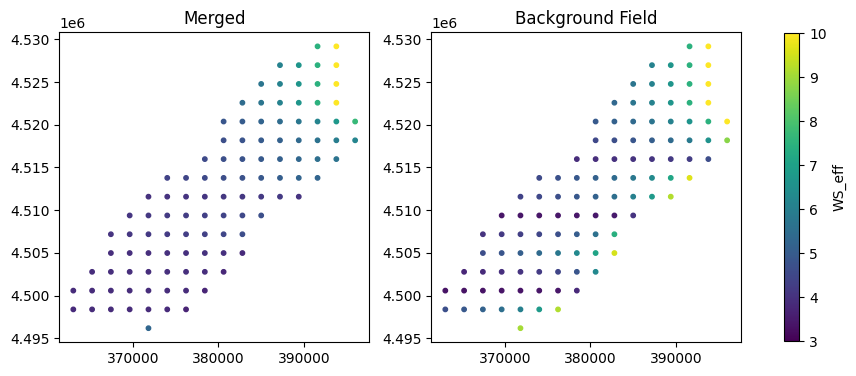

In [15]:
sim_merged_tp, sim_self_tp = sims6["turbopark"]
wd_i6 = SIM_WD.index(90)
ws_truth6 = sim_merged_tp.WS_eff.isel(wt=self_idx6, wd=wd_i6, ws=0).values
ws_bg6 = sim_self_tp.WS_eff.isel(wd=wd_i6, ws=0).values

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
vmin, vmax = 3, 10
axes[0].scatter(self_x6, self_y6, c=ws_truth6, cmap="viridis", vmin=vmin, vmax=vmax, s=10)
axes[0].set_aspect("equal")
axes[0].set_title("Merged")
sc6 = axes[1].scatter(self_x6, self_y6, c=ws_bg6, cmap="viridis", vmin=vmin, vmax=vmax, s=10)
axes[1].set_aspect("equal")
axes[1].set_title("Background Field")
fig.colorbar(sc6, ax=axes, shrink=0.8, label="WS_eff")
plt.show()